# Attrition Analysis and Risk Prediction

In [771]:
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [772]:
#Load Data
df=pd.read_csv('messy_employee_attrition_dataset.csv')
print("Data loaded successfully")

Data loaded successfully


## Data Exploration

In [774]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,HireDate,Salary,SalaryHistory,PerformanceRating,WorkLifeBalance,JobSatisfaction,DistanceFromHome,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,ManagerID,EmployeeStatus,Attrition
0,EMP_0140,25.0,female,Married,MA,Marketing,Marketing Analyst,03/11/2019,54113.0,"44434,46957",5.0,3.0,4,6,No,2,2.461659,2022-06-04,11,NaN,Terminated,1
1,EMP_1241,31.0,Female,single,Master,Finance,Accountant,01/15/2016,55770.0,NaN,2.0,4.0,5,3,Y,0,4.154522,2020-01-15,0,MGR_030,Active,0
2,EMP_0128,30.0,F,Single,Bachelor,sales,Account Manager,"June 17, 2022",71495.0,NaN,6.0,5.0,High,15,No,2,5.018754,2021-04-19,8,MGR_014,Resigned,1
3,EMP_1590,35.0,female,married,MA,Sales,Sales Rep,31-01-2022,59345.0,"42817,45915,50861",3.0,4.0,3,3,No,2,0.222418,2019-02-18,0,MGR_164,Active,0
4,EMP_0103,32.0,male,married,Bachelor,Operations,Ops Analyst,2023-01-26,75923.0,"50196,58260,67656",3.0,4.0,2,25,Yes,1,0.351697,2019-12-06,20,NaN,Terminated,1


In [775]:
df.shape

(2040, 22)

In [776]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             2040 non-null   object 
 1   Age                    1979 non-null   float64
 2   Gender                 2040 non-null   object 
 3   MaritalStatus          2040 non-null   object 
 4   Education              2015 non-null   object 
 5   Department             2040 non-null   object 
 6   JobRole                2040 non-null   object 
 7   HireDate               2005 non-null   object 
 8   Salary                 1950 non-null   float64
 9   SalaryHistory          1580 non-null   object 
 10  PerformanceRating      2011 non-null   float64
 11  WorkLifeBalance        1991 non-null   float64
 12  JobSatisfaction        2016 non-null   object 
 13  DistanceFromHome       1981 non-null   object 
 14  Overtime               2022 non-null   object 
 15  NumC

In [777]:
df.describe()

,Age,Salary,PerformanceRating,WorkLifeBalance,NumCompaniesWorked,YearsSincePromotion,TrainingHoursLastYear,Attrition
count,1979.000000,1950.000000,2011.000000,1991.000000,2040.000000,1937.000000,2040.000000,2040.000000
mean,34.939869,74309.909744,3.193933,3.203918,2.155882,1.941297,27.562255,0.297549
std,8.028005,36458.546180,1.048658,1.286812,3.177010,2.000924,236.680779,0.457292
min,15.000000,20000.000000,0.000000,0.000000,-10.000000,-4.264804,-100.000000,0.000000
25%,29.000000,54861.000000,3.000000,2.000000,1.000000,0.578481,6.000000,0.000000
50%,35.000000,67497.000000,3.000000,3.000000,2.000000,1.334777,14.000000,0.000000
75%,40.000000,85564.500000,4.000000,4.000000,3.000000,2.723709,28.000000,1.000000
max,85.000000,500000.000000,6.000000,10.000000,100.000000,13.955413,10000.000000,1.000000


## Data Cleaning

In [779]:
#1. Format issue in categorical Data

categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n {col} - Unique Values:")
    print(df[col].unique())


 EmployeeID - Unique Values:
['EMP_0140' 'EMP_1241' 'EMP_0128' ... 'EMP_1831' 'EMP_1985' 'EMP_1464']

 Gender - Unique Values:
['female' 'Female' 'F' 'male' 'Male' 'M' 'MALE']

 MaritalStatus - Unique Values:
['Married' 'single' 'Single' 'married' 'Divorced' 'M' 'D' 'S']

 Education - Unique Values:
['MA' 'Master' 'Bachelor' 'High School' nan 'Masters' 'Bachelors' 'BA'
 'BS' 'PhD' 'MS' 'High school']

 Department - Unique Values:
['Marketing' 'Finance' 'sales' 'Sales' 'Operations' 'R&D' 'HR'
 'Customer Service' 'Engineering' 'Marketting' 'Customer Support'
 'Human Resources' 'IT' 'Enginnering' 'Engineering ']

 JobRole - Unique Values:
['Marketing Analyst' 'Accountant' 'Account Manager' 'Sales Rep'
 'Ops Analyst' 'Research Scientist' 'Marketing Specialist' 'HR Manager'
 'Sales Representative' 'CS Manager' 'HR Generalist' 'Senior Engineer'
 'Engineering Manager' 'Senior Analyst' 'Operations Manager'
 'Finance Manager' 'Digital Marketer' 'HR Specialist' 'Sales Manager'
 'Recruiter' 'Sup

In [780]:
#cleaning categorical data

cols_to_clean=['Gender','MaritalStatus','Department','JobRole','JobSatisfaction','Overtime','EmployeeStatus']
df[cols_to_clean]=df[cols_to_clean].apply(lambda col : col.str.strip().str.title())

In [781]:
categorical_cols=df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n {col} - Unique Values:")
    print(df[col].unique())


 EmployeeID - Unique Values:
['EMP_0140' 'EMP_1241' 'EMP_0128' ... 'EMP_1831' 'EMP_1985' 'EMP_1464']

 Gender - Unique Values:
['Female' 'F' 'Male' 'M']

 MaritalStatus - Unique Values:
['Married' 'Single' 'Divorced' 'M' 'D' 'S']

 Education - Unique Values:
['MA' 'Master' 'Bachelor' 'High School' nan 'Masters' 'Bachelors' 'BA'
 'BS' 'PhD' 'MS' 'High school']

 Department - Unique Values:
['Marketing' 'Finance' 'Sales' 'Operations' 'R&D' 'Hr' 'Customer Service'
 'Engineering' 'Marketting' 'Customer Support' 'Human Resources' 'It'
 'Enginnering']

 JobRole - Unique Values:
['Marketing Analyst' 'Accountant' 'Account Manager' 'Sales Rep'
 'Ops Analyst' 'Research Scientist' 'Marketing Specialist' 'Hr Manager'
 'Sales Representative' 'Cs Manager' 'Hr Generalist' 'Senior Engineer'
 'Engineering Manager' 'Senior Analyst' 'Operations Manager'
 'Finance Manager' 'Digital Marketer' 'Hr Specialist' 'Sales Manager'
 'Recruiter' 'Support Specialist' 'Financial Analyst' 'Product Developer'
 'Proces

In [782]:
#formatting mix data 
mapping={'M':'Married','S':'Single','D':'Divorced'}
df['MaritalStatus']=df['MaritalStatus'].replace(mapping)

In [783]:
df['MaritalStatus'].unique()

array(['Married', 'Single', 'Divorced'], dtype=object)

In [784]:
mapping={'M':'Male','F':'Female'}
df['Gender']=df['Gender'].replace(mapping)

In [785]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [786]:
#cleaning department

mapping={'Marketting':'Marketing','Human Resources':'Hr','Enginnering':'Engineering' }
df['Department'] =df['Department'].replace(mapping)
         

In [787]:
df['Department'].unique()

array(['Marketing', 'Finance', 'Sales', 'Operations', 'R&D', 'Hr',
       'Customer Service', 'Engineering', 'Customer Support', 'It'],
      dtype=object)

In [788]:

#cleaning Education
mapping={'Master':'Masters','High School':'High school'}
df['Education'] =df['Education'].replace(mapping)


In [789]:
df['Education'].unique()

array(['MA', 'Masters', 'Bachelor', 'High school', nan, 'Bachelors', 'BA',
       'BS', 'PhD', 'MS'], dtype=object)

In [790]:
#claning Job satisfaction
mapping={'Very Low':1,'Low':2,'Medium':3,'High':4,'Very High':5,'4':4,'5':5,'2':2,'1':1,'3':3}
df['JobSatisfaction'] =df['JobSatisfaction'].replace(mapping)


/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/1681878970.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['JobSatisfaction'] =df['JobSatisfaction'].replace(mapping)


In [791]:
df['JobSatisfaction'].unique()

array([ 4.,  5.,  3.,  2.,  1., nan])

In [792]:
#CLEAN overtime
mapping={'No':0,'N':0,'Y':1,'Yes':1,'True':1,'0':0,'1':1,'False':0}
df['Overtime'] =df['Overtime'].replace(mapping)

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/414951201.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Overtime'] =df['Overtime'].replace(mapping)


In [793]:
df['Overtime'].unique()

array([ 0.,  1., nan])

In [794]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'SalaryHistory',
       'PerformanceRating', 'WorkLifeBalance', 'JobSatisfaction',
       'DistanceFromHome', 'Overtime', 'NumCompaniesWorked',
       'YearsSincePromotion', 'LastPromotionDate', 'TrainingHoursLastYear',
       'ManagerID', 'EmployeeStatus', 'Attrition'],
      dtype='object')

In [795]:
#Clean Date
df['HireDate']

0          03/11/2019
1          01/15/2016
2       June 17, 2022
3          31-01-2022
4          2023-01-26
            ...      
2035       2021-09-01
2036       2023-12-27
2037       31-01-2023
2038       2018-08-02
2039       07/11/2019
Name: HireDate, Length: 2040, dtype: object

In [796]:
df['HireDate']=df['HireDate'].astype(str).str.strip()
df['HireDate'].replace(['',' ','nan','NaN','Null','None','--'],pd.NA)
def parse_date_safe(x):
    try:
        return parser.parse(x,dayfirst=False)
    except:
        return pd.NaT
df['HireDate']=df['HireDate'].apply(parse_date_safe)
df['LastPromotionDate']=df['LastPromotionDate'].apply(parse_date_safe)

In [797]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   EmployeeID             2040 non-null   object        
 1   Age                    1979 non-null   float64       
 2   Gender                 2040 non-null   object        
 3   MaritalStatus          2040 non-null   object        
 4   Education              2015 non-null   object        
 5   Department             2040 non-null   object        
 6   JobRole                2040 non-null   object        
 7   HireDate               1947 non-null   datetime64[ns]
 8   Salary                 1950 non-null   float64       
 9   SalaryHistory          1580 non-null   object        
 10  PerformanceRating      2011 non-null   float64       
 11  WorkLifeBalance        1991 non-null   float64       
 12  JobSatisfaction        2016 non-null   float64       
 13  Dis

In [798]:
pd.set_option('display.max_columns', None)
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,HireDate,Salary,SalaryHistory,PerformanceRating,WorkLifeBalance,JobSatisfaction,DistanceFromHome,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,ManagerID,EmployeeStatus,Attrition
0,EMP_0140,25.0,Female,Married,MA,Marketing,Marketing Analyst,2019-03-11,54113.0,"44434,46957",5.0,3.0,4.0,6,0.0,2,2.461659,2022-06-04,11,NaN,Terminated,1
1,EMP_1241,31.0,Female,Single,Masters,Finance,Accountant,2016-01-15,55770.0,NaN,2.0,4.0,5.0,3,1.0,0,4.154522,2020-01-15,0,MGR_030,Active,0
2,EMP_0128,30.0,Female,Single,Bachelor,Sales,Account Manager,2022-06-17,71495.0,NaN,6.0,5.0,4.0,15,0.0,2,5.018754,2021-04-19,8,MGR_014,Resigned,1
3,EMP_1590,35.0,Female,Married,MA,Sales,Sales Rep,2022-01-31,59345.0,"42817,45915,50861",3.0,4.0,3.0,3,0.0,2,0.222418,2019-02-18,0,MGR_164,Active,0
4,EMP_0103,32.0,Male,Married,Bachelor,Operations,Ops Analyst,2023-01-26,75923.0,"50196,58260,67656",3.0,4.0,2.0,25,1.0,1,0.351697,2019-12-06,20,NaN,Terminated,1


In [799]:
df['PerformanceRating'].unique()

array([ 5.,  2.,  6.,  3.,  4., nan,  1.,  0.])

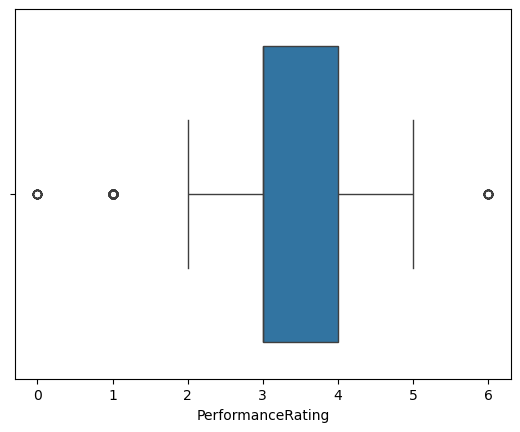

In [800]:
#checking outliars
sns.boxplot(x=df['PerformanceRating'])
plt.show()

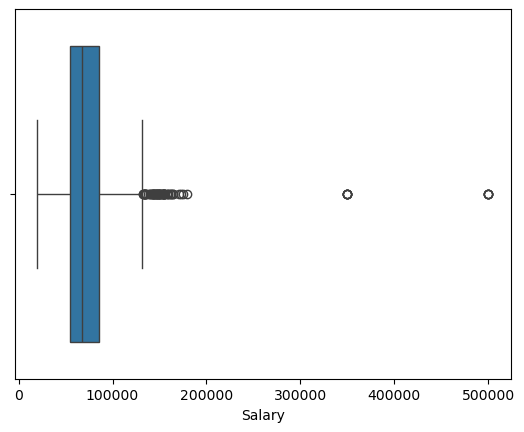

In [801]:
sns.boxplot(x=df['Salary'])
plt.show()

In [802]:
df.describe()

,Age,HireDate,Salary,PerformanceRating,WorkLifeBalance,JobSatisfaction,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,Attrition
count,1979.000000,1947,1950.000000,2011.000000,1991.000000,2016.000000,2022.000000,2040.000000,1937.000000,1821,2040.000000,2040.000000
mean,34.939869,2017-05-29 13:46:07.950693376,74309.909744,3.193933,3.203918,3.185516,0.319980,2.155882,1.941297,2020-06-12 20:08:18.187808768,27.562255,0.297549
min,15.000000,2010-01-04 00:00:00,20000.000000,0.000000,0.000000,1.000000,0.000000,-10.000000,-4.264804,2015-07-02 00:00:00,-100.000000,0.000000
25%,29.000000,2013-08-13 00:00:00,54861.000000,3.000000,2.000000,3.000000,0.000000,1.000000,0.578481,2017-11-08 00:00:00,6.000000,0.000000
50%,35.000000,2017-07-01 00:00:00,67497.000000,3.000000,3.000000,3.000000,0.000000,2.000000,1.334777,2020-06-10 00:00:00,14.000000,0.000000
75%,40.000000,2021-01-21 00:00:00,85564.500000,4.000000,4.000000,4.000000,1.000000,3.000000,2.723709,2023-01-08 00:00:00,28.000000,1.000000
max,85.000000,2024-12-29 00:00:00,500000.000000,6.000000,10.000000,5.000000,1.000000,100.000000,13.955413,2025-05-28 00:00:00,10000.000000,1.000000
std,8.028005,NaN,36458.546180,1.048658,1.286812,1.060132,0.466584,3.177010,2.000924,NaN,236.680779,0.457292


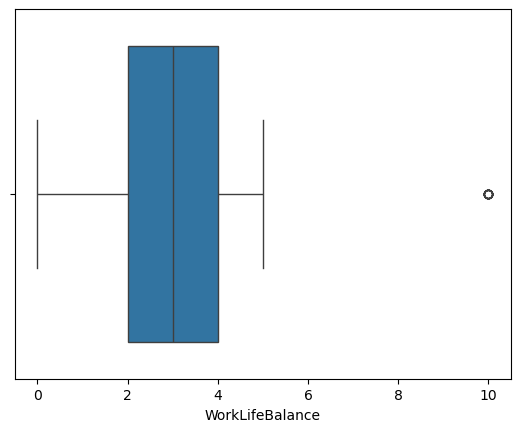

In [803]:
sns.boxplot(x=df['WorkLifeBalance'])
plt.show()

In [804]:
df['WorkLifeBalance'].unique()

array([ 3.,  4.,  5.,  2., nan,  1.,  0., 10.])

In [805]:
mapping={0:0,1:1,2:2,3:3,4:4,5:5,10:5}
df['WorkLifeBalance'] =df['WorkLifeBalance'].replace(mapping)

In [806]:
df['WorkLifeBalance'].unique()

array([ 3.,  4.,  5.,  2., nan,  1.,  0.])

In [807]:
mapping={0:0,1:1,2:2,3:3,4:4,5:5,6:5}
df['PerformanceRating'] =df['PerformanceRating'].replace(mapping)

In [808]:
df['PerformanceRating'].unique()

array([ 5.,  2.,  3.,  4., nan,  1.,  0.])

In [809]:
#Check Duplicates
df.duplicated().sum()

0

In [810]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'SalaryHistory',
       'PerformanceRating', 'WorkLifeBalance', 'JobSatisfaction',
       'DistanceFromHome', 'Overtime', 'NumCompaniesWorked',
       'YearsSincePromotion', 'LastPromotionDate', 'TrainingHoursLastYear',
       'ManagerID', 'EmployeeStatus', 'Attrition'],
      dtype='object')

In [811]:
df['EmployeeID'].duplicated().sum()

0

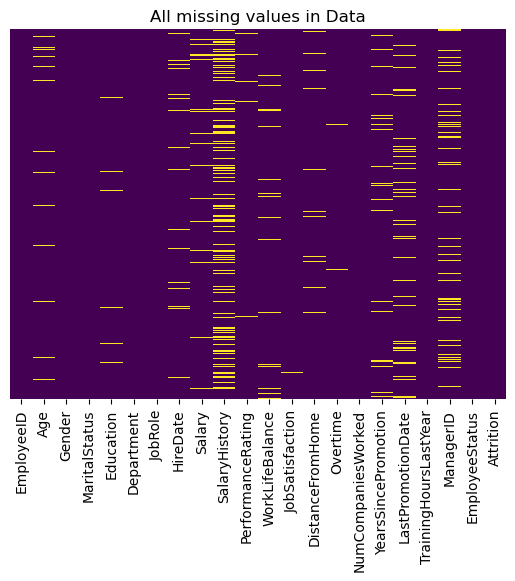

In [812]:
#Check missing values

sns.heatmap(df.isna(),cbar=False,yticklabels=False,cmap='viridis')
plt.title('All missing values in Data')
plt.show()

In [813]:
#filling Missing values
df['Age']=df['Age'].fillna(df['Age'].mode()[0])

In [814]:
df['Education']=df['Education'].fillna('nan')

In [815]:
df['Salary'].isna().sum()

90

In [816]:
df['Salary']=df['Salary'].fillna(df['Salary'].mode()[0])

In [817]:
df=df.drop('SalaryHistory',axis=1)

In [818]:
df.shape

(2040, 21)

In [819]:
df['WorkLifeBalance']=df['WorkLifeBalance'].fillna(df['WorkLifeBalance'].mean())
df['JobSatisfaction']=df['JobSatisfaction'].fillna(df['JobSatisfaction'].mean())
df['PerformanceRating']=df['PerformanceRating'].fillna(df['JobSatisfaction'].mean())
df['Overtime']=df['Overtime'].fillna(df['Overtime'].mean())

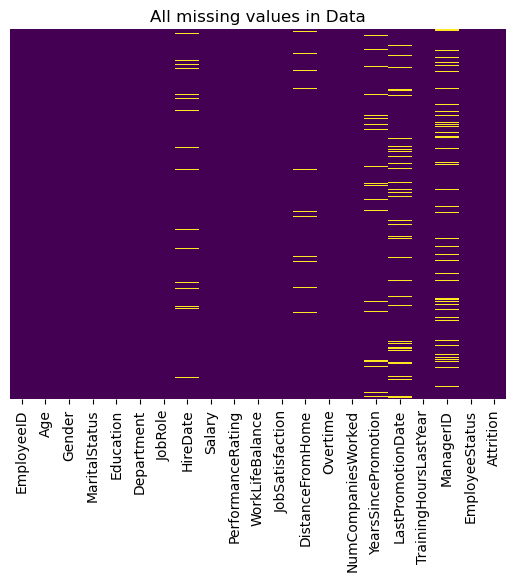

In [820]:
sns.heatmap(df.isna(),cbar=False,yticklabels=False,cmap='viridis')
plt.title('All missing values in Data')
plt.show()

In [821]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,HireDate,Salary,PerformanceRating,WorkLifeBalance,JobSatisfaction,DistanceFromHome,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,ManagerID,EmployeeStatus,Attrition
0,EMP_0140,25.0,Female,Married,MA,Marketing,Marketing Analyst,2019-03-11,54113.0,5.0,3.0,4.0,6,0.0,2,2.461659,2022-06-04,11,NaN,Terminated,1
1,EMP_1241,31.0,Female,Single,Masters,Finance,Accountant,2016-01-15,55770.0,2.0,4.0,5.0,3,1.0,0,4.154522,2020-01-15,0,MGR_030,Active,0
2,EMP_0128,30.0,Female,Single,Bachelor,Sales,Account Manager,2022-06-17,71495.0,5.0,5.0,4.0,15,0.0,2,5.018754,2021-04-19,8,MGR_014,Resigned,1
3,EMP_1590,35.0,Female,Married,MA,Sales,Sales Rep,2022-01-31,59345.0,3.0,4.0,3.0,3,0.0,2,0.222418,2019-02-18,0,MGR_164,Active,0
4,EMP_0103,32.0,Male,Married,Bachelor,Operations,Ops Analyst,2023-01-26,75923.0,3.0,4.0,2.0,25,1.0,1,0.351697,2019-12-06,20,NaN,Terminated,1


## Feature Engineering

In [823]:
# Tenure bucket
# Salary pecentile and growth rates
# Categorical Feature

In [824]:
current_date=datetime(2025,6,28)
df['Tenure_days'] = (current_date-df['HireDate']).dt.days

In [825]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'PerformanceRating',
       'WorkLifeBalance', 'JobSatisfaction', 'DistanceFromHome', 'Overtime',
       'NumCompaniesWorked', 'YearsSincePromotion', 'LastPromotionDate',
       'TrainingHoursLastYear', 'ManagerID', 'EmployeeStatus', 'Attrition',
       'Tenure_days'],
      dtype='object')

In [826]:
#Calculating Salary % and growth rate

percentiles=df['Salary'].quantile([0.25,0.50,0.75,0.9,1.0])
print(percentiles)

0.25     52843.5
0.50     66204.0
0.75     84451.5
0.90    106303.2
1.00    500000.0
Name: Salary, dtype: float64


In [827]:
#75th percentile salary per job level

salary_75th = df.groupby('JobRole')['Salary'].quantile(0.75)
print(salary_75th)

JobRole
Account Manager           78214.00
Accountant                61476.50
Cs Manager                74719.00
Customer Rep              42187.00
Devops Engineer          108680.00
Digital Marketer          65955.00
Engineering Manager      150098.25
Finance Manager          101295.75
Financial Analyst         70607.00
Hr Generalist             54248.00
Hr Manager                84253.00
Hr Specialist             54647.50
It Specialist             82670.00
Jr. Software Engineer     72676.50
Marketing Analyst         64374.00
Marketing Manager         87639.00
Marketing Specialist      61049.25
Operations Analyst        67704.00
Operations Manager        93049.50
Ops Analyst               64426.50
Process Specialist        63784.75
Product Developer         92227.00
R&D Manager              149328.50
Recruiter                 63106.50
Research Scientist       105838.00
Sales Manager             93401.25
Sales Rep                 54247.00
Sales Representative      56760.00
Senior Analy

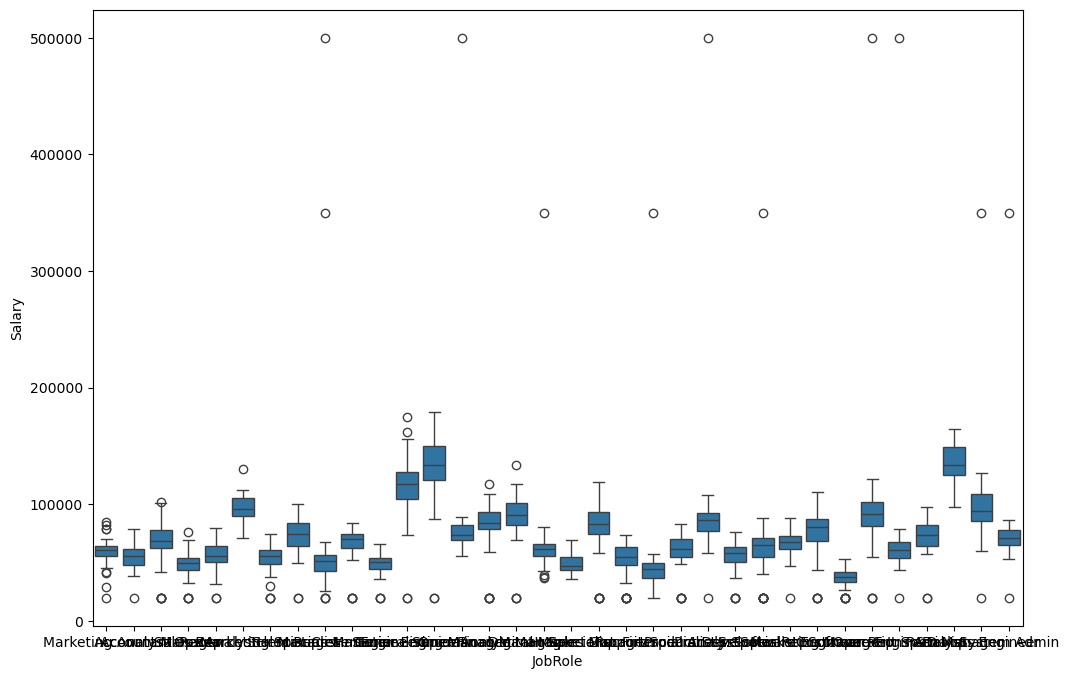

In [828]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df,x='JobRole',y='Salary')
plt.show()

In [829]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,HireDate,Salary,PerformanceRating,WorkLifeBalance,JobSatisfaction,DistanceFromHome,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,ManagerID,EmployeeStatus,Attrition,Tenure_days
0,EMP_0140,25.0,Female,Married,MA,Marketing,Marketing Analyst,2019-03-11,54113.0,5.0,3.0,4.0,6,0.0,2,2.461659,2022-06-04,11,NaN,Terminated,1,2301.0
1,EMP_1241,31.0,Female,Single,Masters,Finance,Accountant,2016-01-15,55770.0,2.0,4.0,5.0,3,1.0,0,4.154522,2020-01-15,0,MGR_030,Active,0,3452.0
2,EMP_0128,30.0,Female,Single,Bachelor,Sales,Account Manager,2022-06-17,71495.0,5.0,5.0,4.0,15,0.0,2,5.018754,2021-04-19,8,MGR_014,Resigned,1,1107.0
3,EMP_1590,35.0,Female,Married,MA,Sales,Sales Rep,2022-01-31,59345.0,3.0,4.0,3.0,3,0.0,2,0.222418,2019-02-18,0,MGR_164,Active,0,1244.0
4,EMP_0103,32.0,Male,Married,Bachelor,Operations,Ops Analyst,2023-01-26,75923.0,3.0,4.0,2.0,25,1.0,1,0.351697,2019-12-06,20,NaN,Terminated,1,884.0


In [830]:
Attrition_Rate= (df['Attrition'].value_counts(normalize=True)[1]*100)

In [831]:
print(f" Attrition Rate:{round(Attrition_Rate,2)}%")

 Attrition Rate:29.75%


In [832]:
Attrition_count = df['Attrition'].value_counts()
Attrition_count

Attrition
0    1433
1     607
Name: count, dtype: int64

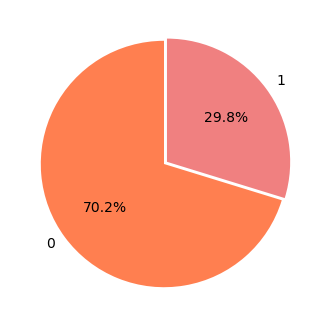

In [833]:
plt.figure(figsize=(4,4))
plt.pie(Attrition_count,labels=Attrition_count.index,autopct='%1.1f%%',startangle=90,colors=['coral','lightcoral'],explode=[0,0.03])

plt.show()

In [834]:
#Attriation by department

Attriation_by_department = df.groupby('Department',as_index=False)['Attrition'].value_counts()

<Figure size 1200x600 with 0 Axes>

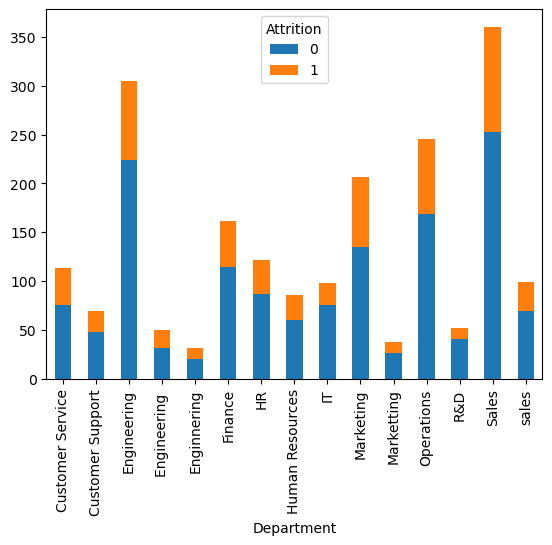

In [914]:
df1=pd.read_csv('messy_employee_attrition_dataset.csv')
plt.figure(figsize=(12,6))
pd.crosstab(df1['Department'],df1['Attrition']).plot(kind='bar',stacked=True)
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

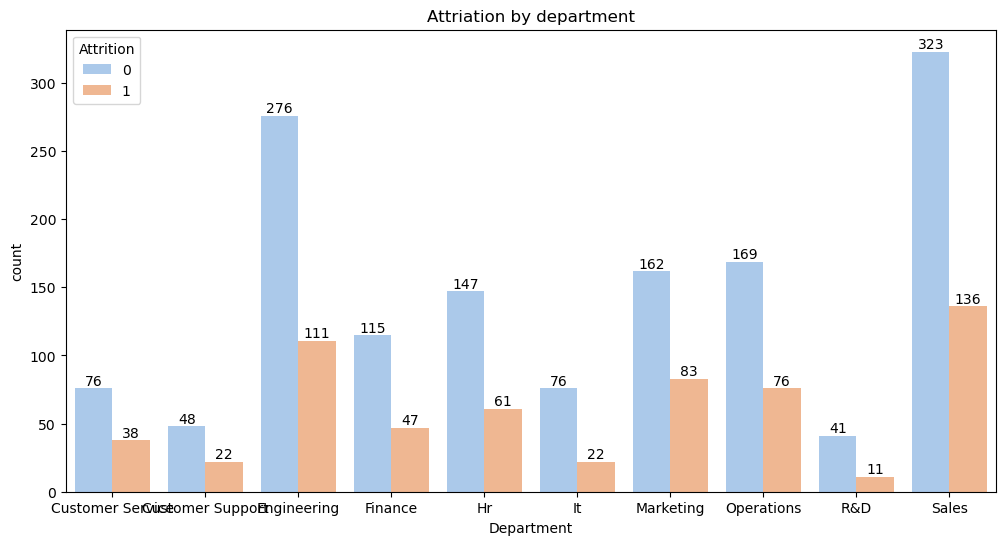

In [835]:
plt.figure(figsize=(12,6))
ax=sns.barplot(data=Attriation_by_department,x='Department',y='count',hue='Attrition',palette='pastel')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attriation by department')
plt.show()

In [836]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'PerformanceRating',
       'WorkLifeBalance', 'JobSatisfaction', 'DistanceFromHome', 'Overtime',
       'NumCompaniesWorked', 'YearsSincePromotion', 'LastPromotionDate',
       'TrainingHoursLastYear', 'ManagerID', 'EmployeeStatus', 'Attrition',
       'Tenure_days'],
      dtype='object')

In [837]:
#Attriation by Job Level


Attriation_by_JobRole = df[df['Attrition'] == 1].groupby('JobRole',as_index=False)['Attrition'].value_counts().sort_values('count',ascending=False)

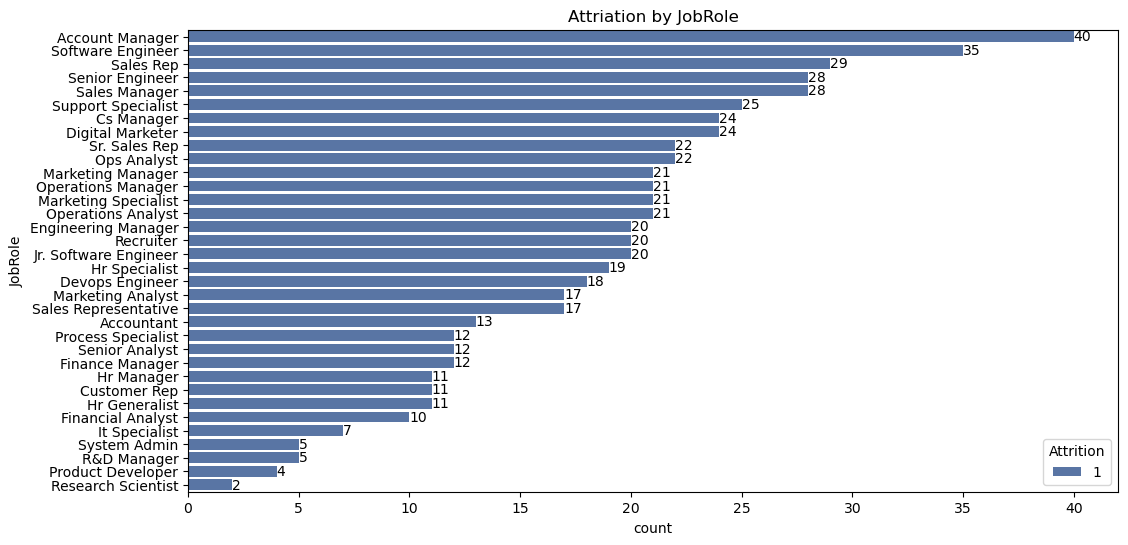

In [838]:
plt.figure(figsize=(12,6))
ax=sns.barplot(data=Attriation_by_JobRole,x='count',y='JobRole',hue='Attrition',palette='deep')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attriation by JobRole')
plt.show()

In [839]:
Total = df[df['Attrition'] == 1].shape[0]
Total

607

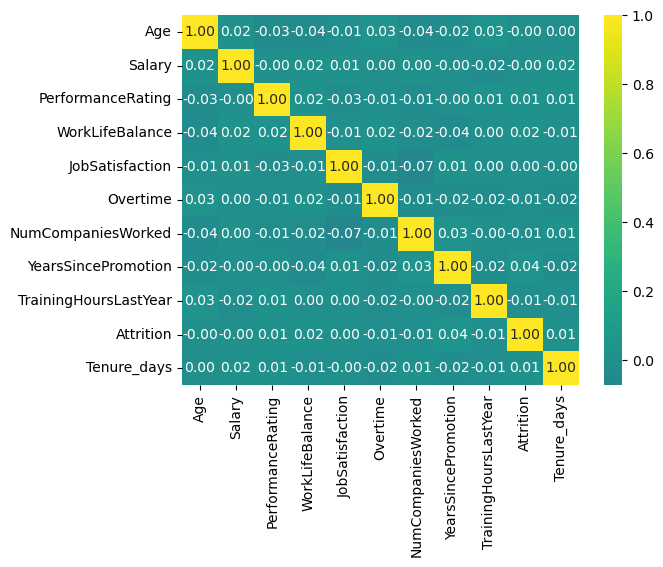

In [840]:
corr_matrix=df.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,cmap='viridis',fmt=".2f",center=0)
plt.show()
                

In [841]:
attrition_corr = corr_matrix['Attrition'].sort_values(ascending=False)
print(attrition_corr)

Attrition                1.000000
YearsSincePromotion      0.035393
WorkLifeBalance          0.021085
Tenure_days              0.010263
PerformanceRating        0.009836
JobSatisfaction          0.002098
Age                     -0.002908
Salary                  -0.003805
NumCompaniesWorked      -0.007636
TrainingHoursLastYear   -0.007759
Overtime                -0.009115
Name: Attrition, dtype: float64


In [842]:
#Compute corelation with Attrition

corr_matrix=df.corr(numeric_only=True)
attrition_corr=corr_matrix['Attrition'].drop('Attrition')

In [843]:
#get 5 most absolute corelation

top_5_features=attrition_corr.reindex(attrition_corr.abs().sort_values(ascending=False).index)[:5]
print(top_5_features)

YearsSincePromotion    0.035393
WorkLifeBalance        0.021085
Tenure_days            0.010263
PerformanceRating      0.009836
Overtime              -0.009115
Name: Attrition, dtype: float64


/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/2130994620.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5_features.values,y=top_5_features.index,palette='coolwarm')


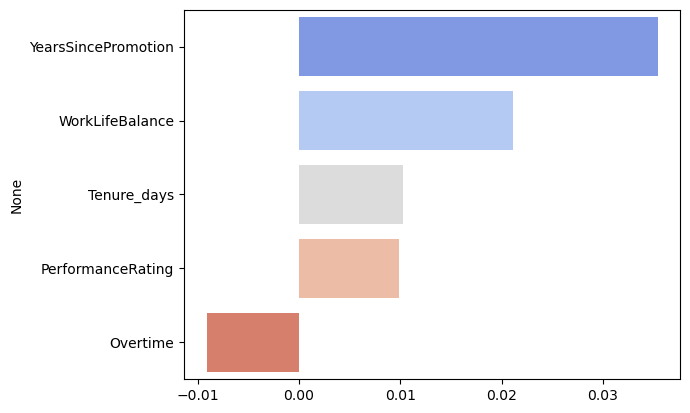

In [844]:
sns.barplot(x=top_5_features.values,y=top_5_features.index,palette='coolwarm')
plt.show()

In [845]:
df=df.drop('EmployeeStatus',axis=1)

In [846]:
df.shape

(2040, 21)

In [847]:
#Top 5 categorical Feaures which is cause of leaving

#Encode categorical variables
df_encoded=pd.get_dummies(df,drop_first=True)
cat_corr=df_encoded.corr(numeric_only=True)['Attrition'].drop('Attrition').sort_values(key=abs,ascending=False)

In [848]:
cat_corr


DistanceFromHome_28    0.065827
ManagerID_MGR_042      0.062786
ManagerID_MGR_144      0.062097
DistanceFromHome_15    0.054892
ManagerID_MGR_166      0.054567
                         ...   
ManagerID_MGR_017      0.000376
ManagerID_MGR_018      0.000376
ManagerID_MGR_181      0.000376
ManagerID_MGR_143      0.000376
ManagerID_MGR_186      0.000376
Name: Attrition, Length: 2354, dtype: float64

In [849]:
top_cat_corr = cat_corr.head(10)
top_cat_corr

DistanceFromHome_28           0.065827
ManagerID_MGR_042             0.062786
ManagerID_MGR_144             0.062097
DistanceFromHome_15           0.054892
ManagerID_MGR_166             0.054567
ManagerID_MGR_008             0.053488
ManagerID_MGR_059             0.053488
JobRole_Research Scientist   -0.051124
ManagerID_MGR_070             0.048085
ManagerID_MGR_126            -0.047921
Name: Attrition, dtype: float64

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/388979675.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat_corr.values,y=top_cat_corr.index,palette='Spectral')


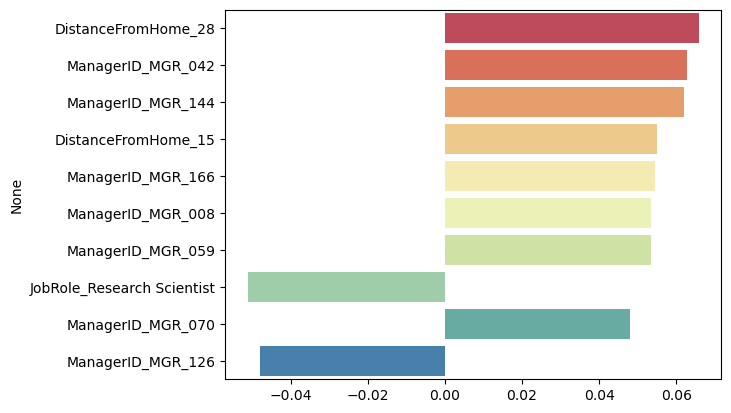

In [850]:
sns.barplot(x=top_cat_corr.values,y=top_cat_corr.index,palette='Spectral')
plt.show()

In [851]:
from scipy.stats import chi2_contingency

table=pd.crosstab(df['JobRole'],df['Attrition'])
chi2,p,dof,expected=chi2_contingency(table)
print(f"Chi-Square:{chi2:.2f}")
print(f" P-Value:{p:.4f}")

Chi-Square:30.20
 P-Value:0.6072


In [852]:
table=pd.crosstab(df['Department'],df['Attrition'])
chi2,p,dof,expected=chi2_contingency(table)
print(f"Chi-Square:{chi2:.2f}")
print(f" P-Value:{p:.4f}")

Chi-Square:7.59
 P-Value:0.5756


In [853]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'PerformanceRating',
       'WorkLifeBalance', 'JobSatisfaction', 'DistanceFromHome', 'Overtime',
       'NumCompaniesWorked', 'YearsSincePromotion', 'LastPromotionDate',
       'TrainingHoursLastYear', 'ManagerID', 'Attrition', 'Tenure_days'],
      dtype='object')

In [854]:
df['Salary_bin'] = pd.qcut(df['Salary'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

table=pd.crosstab(df['PerformanceRating'],df['Attrition'])
chi2,p,dof,expected=chi2_contingency(table)
print(f"Chi-Square:{chi2:.2f}")
print(f" P-Value:{p:.4f}")

Chi-Square:4.88
 P-Value:0.5587


In [858]:


distance_map = {
    'Near': 1,
    'Close': 2,
    'Remote': 5,
    'Very Far': 4
}

# Updated function
def convert_distance(val):
    val_str = str(val)
    if val_str.isdigit():
        return int(val_str)
    else:
        return distance_map.get(val_str, np.nan)  # map known strings or NaN

# Apply the function
df['DistanceFromHome'] = df['DistanceFromHome'].apply(convert_distance)


## Modeling

In [860]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'PerformanceRating',
       'WorkLifeBalance', 'JobSatisfaction', 'DistanceFromHome', 'Overtime',
       'NumCompaniesWorked', 'YearsSincePromotion', 'LastPromotionDate',
       'TrainingHoursLastYear', 'ManagerID', 'Attrition', 'Tenure_days',
       'Salary_bin'],
      dtype='object')

In [862]:
#Importing all libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

In [864]:
#Handling missing data

#for numerical values
num_cols=df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    df[col].fillna(df[col].median(),inplace=True)

#for categorical values
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0],inplace=True)

/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/3175261527.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(),inplace=True)
/var/folders/3f/21w5vqzs3k35ybl9kpx55zk40000gn/T/ipykernel_79869/3175261527.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

In [866]:
df.head()

,EmployeeID,Age,Gender,MaritalStatus,Education,Department,JobRole,HireDate,Salary,PerformanceRating,WorkLifeBalance,JobSatisfaction,DistanceFromHome,Overtime,NumCompaniesWorked,YearsSincePromotion,LastPromotionDate,TrainingHoursLastYear,ManagerID,Attrition,Tenure_days,Salary_bin
0,EMP_0140,25.0,Female,Married,MA,Marketing,Marketing Analyst,2019-03-11,54113.0,5.0,3.0,4.0,6.0,0.0,2,2.461659,2022-06-04,11,MGR_084,1,2301.0,Medium
1,EMP_1241,31.0,Female,Single,Masters,Finance,Accountant,2016-01-15,55770.0,2.0,4.0,5.0,3.0,1.0,0,4.154522,2020-01-15,0,MGR_030,0,3452.0,Medium
2,EMP_0128,30.0,Female,Single,Bachelor,Sales,Account Manager,2022-06-17,71495.0,5.0,5.0,4.0,15.0,0.0,2,5.018754,2021-04-19,8,MGR_014,1,1107.0,High
3,EMP_1590,35.0,Female,Married,MA,Sales,Sales Rep,2022-01-31,59345.0,3.0,4.0,3.0,3.0,0.0,2,0.222418,2019-02-18,0,MGR_164,0,1244.0,Medium
4,EMP_0103,32.0,Male,Married,Bachelor,Operations,Ops Analyst,2023-01-26,75923.0,3.0,4.0,2.0,25.0,1.0,1,0.351697,2019-12-06,20,MGR_084,1,884.0,High


In [868]:
df.columns

Index(['EmployeeID', 'Age', 'Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole', 'HireDate', 'Salary', 'PerformanceRating',
       'WorkLifeBalance', 'JobSatisfaction', 'DistanceFromHome', 'Overtime',
       'NumCompaniesWorked', 'YearsSincePromotion', 'LastPromotionDate',
       'TrainingHoursLastYear', 'ManagerID', 'Attrition', 'Tenure_days',
       'Salary_bin'],
      dtype='object')

In [870]:
#Encode categorical variables

# For binary or ordinal categories use LabelEncoder
le=LabelEncoder()

# Example for binary columns like 'Overtime' (Yes/No)
df=pd.get_dummies(df,columns=['Gender', 'MaritalStatus', 'Education',
       'Department', 'JobRole','Salary_bin'])

In [872]:
df.shape

(2040, 79)

In [874]:
#select feature and target

X=df.drop(columns=['EmployeeID','HireDate',
       'LastPromotionDate', 'ManagerID', 'Attrition'])

#target variable
y=df['Attrition']

In [876]:
#split dataset into training and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [878]:
# 4. Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [882]:
#Apply model
model = LogisticRegression()
model.fit(X_train, y_train)



LogisticRegression()

In [884]:
#make prediction
y_pred = model.predict(X_test)


In [886]:
#Evalute the Model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.696078431372549

Confusion Matrix:
 [[282   1]
 [123   2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      1.00      0.82       283
           1       0.67      0.02      0.03       125

    accuracy                           0.70       408
   macro avg       0.68      0.51      0.43       408
weighted avg       0.69      0.70      0.58       408



In [888]:
#which feature are impacting the prediction most
coeff_df = pd.DataFrame(model.coef_[0], index=X.columns, columns=['Coefficient'])
print(coeff_df.sort_values(by='Coefficient', ascending=False))


                             Coefficient
Department_It                   0.120513
YearsSincePromotion             0.102573
JobRole_Devops Engineer         0.099637
JobRole_Engineering Manager     0.098253
WorkLifeBalance                 0.087409
...                                  ...
Department_Engineering         -0.093374
JobRole_Research Scientist     -0.163683
TrainingHoursLastYear          -0.176752
JobRole_It Specialist          -0.192535
JobRole_System Admin           -0.195855

[74 rows x 1 columns]


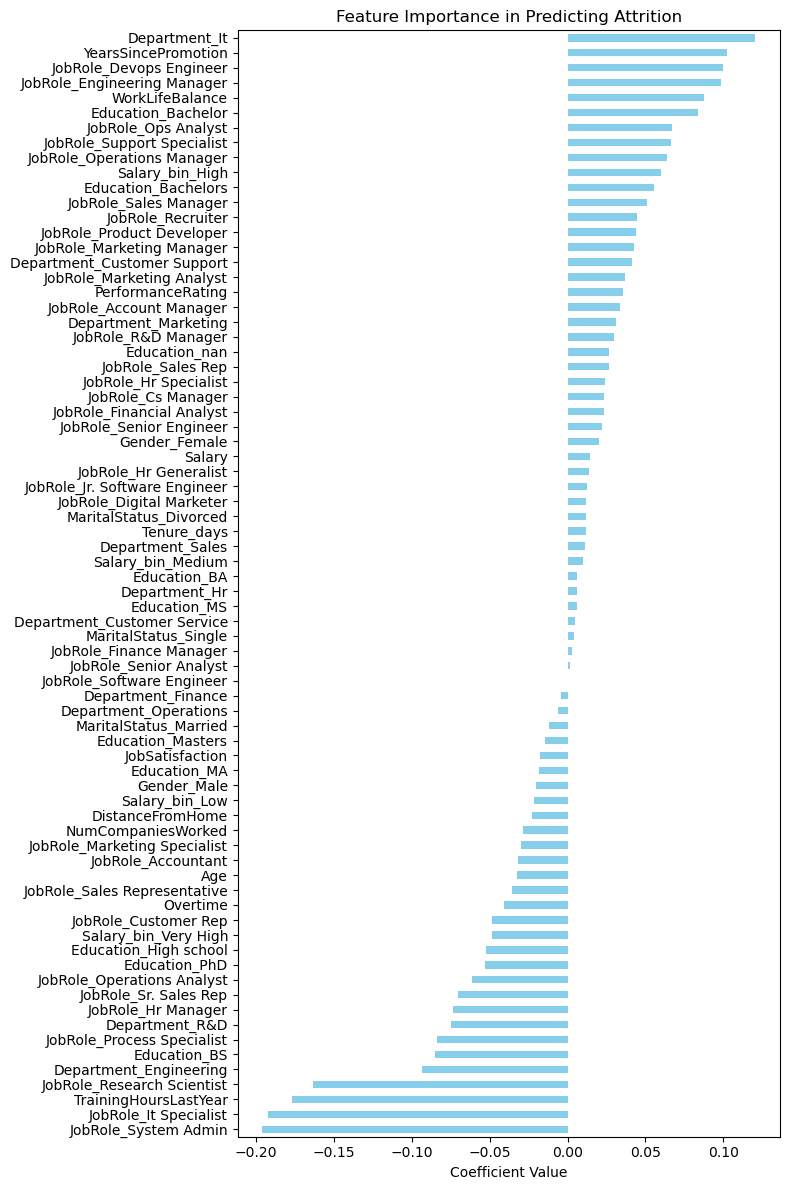

In [904]:
# Sort coefficients
coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()

# Plot
plt.figure(figsize=(8, 12))
coefficients.plot(kind='barh', color='skyblue')
plt.title('Feature Importance in Predicting Attrition')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# Business Summary: Employee Attrition Analysis

The logistic regression model was trained to understand the key drivers of employee attrition. The coefficients from the model represent how strongly each feature is associated with the likelihood of an employee leaving the organization.

📈 Top Positive Drivers (Increase Likelihood of Staying)
These features reduce the chance of attrition:

Department_IT (+0.12): Employees in the IT department are less likely to leave.
YearsSincePromotion (+0.10): Employees who haven't been promoted recently are more likely to stay — possibly indicating satisfaction or stagnation.
JobRole_DevOps Engineer (+0.10) and Engineering Manager (+0.098): These roles are associated with lower attrition, suggesting strong engagement or competitive compensation.
WorkLifeBalance (+0.087): Higher balance correlates with lower attrition, confirming work-life support reduces turnover.
📉 Top Negative Drivers (Increase Likelihood of Leaving)
These features increase the chance of attrition:

JobRole_System Admin (-0.196) and IT Specialist (-0.193): These roles have the highest risk of attrition. This may indicate dissatisfaction, high stress, or uncompetitive compensation.
TrainingHoursLastYear (-0.177): Surprisingly, more training correlates with higher attrition, possibly because employees are becoming more marketable.
JobRole_Research Scientist (-0.164): This role may lack growth opportunities or recognition.
Department_Engineering (-0.093): Engineering department members are more prone to leave compared to others.

# ✅ Recommendations

1. Focus Retention Efforts on High-Risk Roles
System Admins, IT Specialists, and Research Scientists need attention. Conduct exit interviews, engagement surveys, and benchmark compensation for these roles.
2. Review Training Programs
Investigate why training is leading to attrition:
Are employees being trained but not promoted?
Are they using training as a springboard to leave?
You may want to link training to visible growth opportunities.
3. Support Engineering Department
Provide structured career progression and recognition in the Engineering department, which is showing higher-than-average attrition.
4. Leverage Insights from Stable Roles
DevOps Engineers and Engineering Managers are more likely to stay. Analyze what’s working well in those roles (leadership style, compensation, autonomy) and replicate across other functions.
5. Continue Promoting Work-Life Balance
Maintain or expand flexible work policies, hybrid options, and wellness programs to support retention across the board.
6. Utilize Promotions Strategically
Employees with longer gaps since promotion show lower attrition, but this might hint at either stability or stagnation. You may want to ensure that promotion processes are clear, fair, and well-communicated.
